<a href="https://colab.research.google.com/github/Henrixfs/Proyecto_ML_Seguridad/blob/main/TRAIN_MODEL_SQL_Injection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os


# Configurar dispositivo (Usar GPU si está disponible en Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Entrenando en dispositivo: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Entrenando en dispositivo: cuda


In [ ]:
# Rutas en Google Drive (Asegúrate de haber montado el drive antes)
drive_dir = '/content/drive/MyDrive/Proyecto_ML_Seguridad'

# Cargar tensores
X_train, y_train = torch.load(f'{drive_dir}/train_data.pt')
X_val, y_val = torch.load(f'{drive_dir}/val_data.pt')
X_test, y_test = torch.load(f'{drive_dir}/test_data.pt')

# Crear DataLoaders (Lotes de 64 para optimizar memoria)
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"✅ Datos cargados. Muestras de entrenamiento: {len(X_train)}")

✅ Datos cargados. Muestras de entrenamiento: 15483


In [ ]:
# ==========================================
# BLOQUE 2: Arquitectura AttackClassifier
# ==========================================
class AttackClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AttackClassifier, self).__init__()

        # Capa de entrada (Linear -> ReLU)
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3) # Evita el sobreajuste

        # Mecanismo de Atención (El corazón de los Transformers)
        # Permite a la red "prestar atención" a las características más relevantes
        self.attention = nn.MultiheadAttention(embed_dim=256, num_heads=4, batch_first=True)

        # Capa de salida (Linear)
        self.fc2 = nn.Linear(256, num_classes)

        # Nota: CrossEntropyLoss de PyTorch ya aplica Softmax internamente.
        # No ponemos nn.Softmax() al final para no afectar la estabilidad numérica.

    def forward(self, x):
        # Paso 1: Extracción de características
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Paso 2: Mecanismo de Atención (Transformer vibe)
        # MultiheadAttention espera secuencias, así que le damos una dimensión extra simulada
        x = x.unsqueeze(1) # [batch, 1, 256]
        attn_output, _ = self.attention(x, x, x)
        x = attn_output.squeeze(1) # Volvemos a [batch, 256]

        # Paso 3: Clasificación final
        out = self.fc2(x)
        return out

# Instanciar el modelo
input_dim = X_train.shape[1]  # 5000 (por el TF-IDF)
num_classes = 3               # Normal(0), SQLi(1), XSS(2)

model = AttackClassifier(input_dim, num_classes).to(device)
print(model)

AttackClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)


In [ ]:
# ==========================================
# BLOQUE 3: Proceso de Entrenamiento (Actualizado)
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
best_val_loss = float('inf')

# Diccionario para guardar el historial y poder graficar después
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Iniciando entrenamiento...")
for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Calcular precisión de entrenamiento
        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = correct_train / total_train

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

            # Calcular precisión de validación
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    # Guardar en el historial
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} - Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Guardar temporalmente el mejor modelo
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), f'{drive_dir}/model_best.pt')

print("✅ Entrenamiento finalizado.")

Iniciando entrenamiento...
Epoch [1/10] | Train Loss: 0.0800 - Train Acc: 0.9738 | Val Loss: 0.0067 - Val Acc: 0.9976
Epoch [2/10] | Train Loss: 0.0058 - Train Acc: 0.9983 | Val Loss: 0.0106 - Val Acc: 0.9970
Epoch [3/10] | Train Loss: 0.0016 - Train Acc: 0.9995 | Val Loss: 0.0059 - Val Acc: 0.9982
Epoch [4/10] | Train Loss: 0.0008 - Train Acc: 0.9996 | Val Loss: 0.0085 - Val Acc: 0.9976
Epoch [5/10] | Train Loss: 0.0006 - Train Acc: 0.9997 | Val Loss: 0.0062 - Val Acc: 0.9988
Epoch [6/10] | Train Loss: 0.0006 - Train Acc: 0.9998 | Val Loss: 0.0109 - Val Acc: 0.9985
Epoch [7/10] | Train Loss: 0.0016 - Train Acc: 0.9997 | Val Loss: 0.0092 - Val Acc: 0.9982
Epoch [8/10] | Train Loss: 0.0000 - Train Acc: 1.0000 | Val Loss: 0.0096 - Val Acc: 0.9982
Epoch [9/10] | Train Loss: 0.0000 - Train Acc: 1.0000 | Val Loss: 0.0103 - Val Acc: 0.9985
Epoch [10/10] | Train Loss: 0.0000 - Train Acc: 1.0000 | Val Loss: 0.0108 - Val Acc: 0.9982
✅ Entrenamiento finalizado.


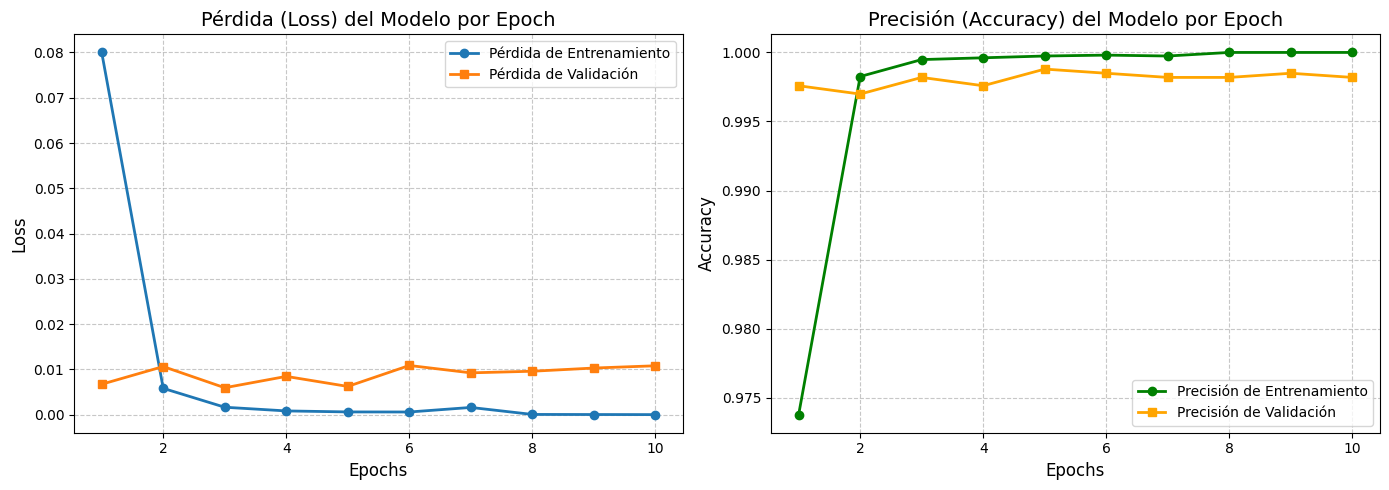

In [ ]:
# ==========================================
# BLOQUE 3.5: Gráficas de Pérdida y Precisión
# ==========================================
import matplotlib.pyplot as plt

# Crear un rango para el eje X (1, 2, 3... hasta el total de epochs)
epochs_range = range(1, epochs + 1)

# Configurar el tamaño de la figura (ancho, alto)
plt.figure(figsize=(14, 5))

# --- GRÁFICA 1: Pérdida (Loss) ---
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, gráfica 1
plt.plot(epochs_range, history['train_loss'], label='Pérdida de Entrenamiento', marker='o', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Pérdida de Validación', marker='s', linewidth=2)
plt.title('Pérdida (Loss) del Modelo por Epoch', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- GRÁFICA 2: Precisión (Accuracy) ---
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, gráfica 2
plt.plot(epochs_range, history['train_acc'], label='Precisión de Entrenamiento', marker='o', color='green', linewidth=2)
plt.plot(epochs_range, history['val_acc'], label='Precisión de Validación', marker='s', color='orange', linewidth=2)
plt.title('Precisión (Accuracy) del Modelo por Epoch', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar gráficas de forma limpia
plt.tight_layout()
plt.show()

📊 Resultados de la Evaluación (Test Set):
Accuracy:  0.9949
Precision: 0.9949
Recall:    0.9949



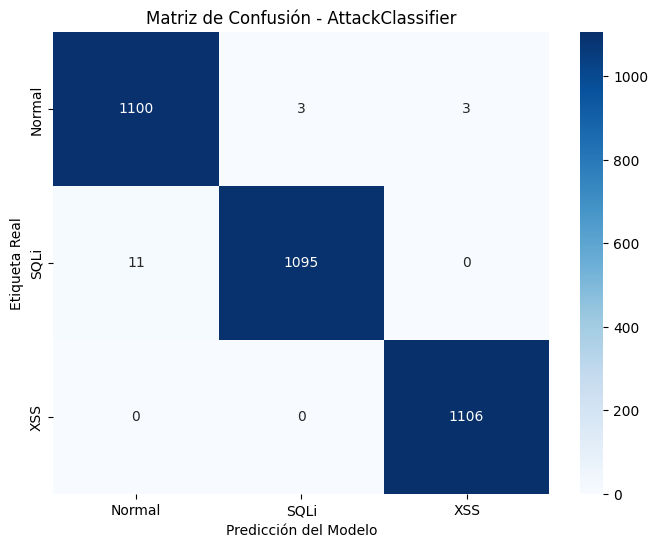

In [ ]:
# ==========================================
# BLOQUE 4: Evaluación y Matriz de Confusión
# ==========================================
# Cargar los mejores pesos obtenidos
model.load_state_dict(torch.load(f'{drive_dir}/model_best.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Calcular Métricas
accuracy = accuracy_score(all_labels, all_preds)
# Usamos 'macro' para ver el promedio balanceado entre las 3 clases
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print(f"📊 Resultados de la Evaluación (Test Set):")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}\n")

# Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'SQLi', 'XSS'],
            yticklabels=['Normal', 'SQLi', 'XSS'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión - AttackClassifier')
plt.show()

In [ ]:
# ==========================================
# BLOQUE 5: Guardar Modelo Final (.pt)
# ==========================================
# Guardar el modelo completo (arquitectura + pesos)
# Esto facilita la carga en FastAPI sin tener que reescribir la clase
final_model_path = f'{drive_dir}/model.pt'
torch.save(model, final_model_path)

print(f"✅ ¡Misión cumplida! Modelo guardado exitosamente para el equipo de Backend en:")
print(f"-> {final_model_path}")

✅ ¡Misión cumplida! Modelo guardado exitosamente para el equipo de Backend en:
-> /content/drive/MyDrive/Proyecto_ML_Seguridad/model.pt
